In [5]:
#Import libraries
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import mpl_axes_aligner
from factor_analyzer.rotator import Rotator

In [6]:
#inlezen data
df = pd.read_csv('Stemwijzer2023.csv')
df.head()


,Partij,Vee,Benzine,EigenRisico,RegioKiezen,OV65,CO2,SuriVisum,Definsie2p,CultOnderwijs,...,ElektrAuto,MinLoon,BouwenLG,Referendum,Vuurwerk,Duurzaam,VoltooidLeven,Asiel,Huurstijging,MinStraf
0,VVD,0,2,0,0,0,2,0,2,0,...,0,0,2,0,0,0,2,2,0,2
1,D66,2,0,0,2,0,2,2,2,2,...,0,2,2,2,2,0,2,2,2,0
2,GLPvdA,2,0,2,0,0,0,2,2,2,...,0,2,2,2,2,0,2,0,2,0
3,PVV,0,2,2,0,2,0,0,0,0,...,2,2,0,2,0,2,1,2,2,2
4,CDA,0,2,0,2,0,0,2,2,0,...,0,0,2,0,0,0,0,2,0,0


In [7]:
#hoeveel parten zijn er
Aantal_partinen = len(df.columns) - 1
print(Aantal_partinen)

30


In [8]:
#hoeveel rijen zijn er
Aantal_rijen = len(df)
print(Aantal_rijen)

23


In [9]:
#Gemiddelde standpunten per partij berekenen plus naam van de partijen
Gemiddelde_standpunten = df.iloc[:, 1:].mean()
Gemiddelde_standpunten.index = df.columns[1:]
print(Gemiddelde_standpunten)

Vee                 0.565217
Benzine             1.304348
EigenRisico         1.130435
RegioKiezen         0.782609
OV65                1.086957
CO2                 0.521739
SuriVisum           1.304348
Definsie2p          1.304348
CultOnderwijs       1.043478
Kerncentrales       1.391304
Vliegtax            1.130435
Kopenhuurw          1.086957
KinderOpv           1.217391
GezinsHer           0.956522
VermogensTax        1.000000
ContrReliGroep      0.869565
Stikstof            0.695652
Kostendeler         1.260870
UitbredingEU        0.739130
RisicoProfileren    1.478261
ElektrAuto          1.043478
MinLoon             1.217391
BouwenLG            1.130435
Referendum          1.391304
Vuurwerk            0.956522
Duurzaam            0.913043
VoltooidLeven       1.217391
Asiel               1.130435
Huurstijging        1.130435
MinStraf            0.869565
dtype: float64


In [10]:
#pca analyse 
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.iloc[:, 1:])

Eigenwaarden (verklaarde variantie):
[1.00987947e+01 4.55835195e+00 2.96115453e+00 2.64371926e+00
 2.25526043e+00 1.76839870e+00 1.33968973e+00 8.65502472e-01
 8.50377202e-01 6.78114637e-01 6.53859657e-01 5.37021254e-01
 4.63850941e-01 3.98749126e-01 3.15398027e-01 2.45929188e-01
 2.14642539e-01 1.82396542e-01 1.43356376e-01 1.02411458e-01
 5.85616471e-02 2.80959949e-02 3.47685097e-32]

Eigenwaarden ratio (percentage verklaarde variantie):
[3.21990556e-01 1.45338758e-01 9.44136228e-02 8.42924980e-02
 7.19068542e-02 5.63837267e-02 4.27147449e-02 2.75957310e-02
 2.71134760e-02 2.16210464e-02 2.08476992e-02 1.71224168e-02
 1.47894503e-02 1.27137402e-02 1.00561690e-02 7.84122048e-03
 6.84367516e-03 5.81554193e-03 4.57078300e-03 3.26529286e-03
 1.86718295e-03 8.95814329e-04 1.10856118e-33]

Vorm van eigenvectoren matrix: (23, 30)
(Elke rij is een eigenvector/principal component)


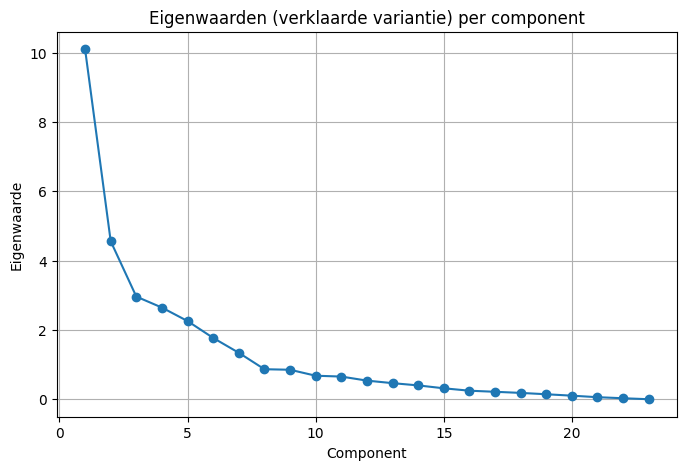

In [11]:
#3.	Bepalen van eigenwaarden en eigenvectoren: Deze wiskundige begrippen geven richting en grootte van de variantie in de data aan
# Extract party data (exclude first column 'Partij') and transpose for PCA
partij_data = df.iloc[:, 1:]  # All columns except first (Partij)
partij_data_scaled = df_scaled  # Use the already scaled data

pca = PCA()
pca.fit(partij_data_scaled)
eigenwaarden = pca.explained_variance_
eigenvectoren = pca.components_

print("Eigenwaarden (verklaarde variantie):")
print(eigenwaarden)
print("\nEigenwaarden ratio (percentage verklaarde variantie):")
print(pca.explained_variance_ratio_)
print(f"\nVorm van eigenvectoren matrix: {eigenvectoren.shape}")
print("(Elke rij is een eigenvector/principal component)")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenwaarden) + 1), eigenwaarden, marker='o')
plt.title("Eigenwaarden (verklaarde variantie) per component")
plt.xlabel("Component")
plt.ylabel("Eigenwaarde")
plt.grid()
plt.show()

In [14]:
# Voorbeeld interpretatie van correlatiematrix resultaten
print("Voorbeelden van wat hoge correlatie betekent:")
print()
print("Als VVD en CDA correlatie = +0.85 hebben:")
print("→ Ze stemmen op 85% van onderwerpen hetzelfde")
print("→ Mogelijke coalitiepartners")
print("→ Vergelijkbare ideologische basis")
print()
print("Als PVV en GL correlatie = -0.75 hebben:")
print("→ Ze zijn het op 75% van onderwerpen oneens")
print("→ Tegengestelde politieke visies")
print("→ Weinig kans op samenwerking")

Voorbeelden van wat hoge correlatie betekent:

Als VVD en CDA correlatie = +0.85 hebben:
→ Ze stemmen op 85% van onderwerpen hetzelfde
→ Mogelijke coalitiepartners
→ Vergelijkbare ideologische basis

Als PVV en GL correlatie = -0.75 hebben:
→ Ze zijn het op 75% van onderwerpen oneens
→ Tegengestelde politieke visies
→ Weinig kans op samenwerking


Eigenwaarden (verklaarde variantie):
[1.00987947e+01 4.55835195e+00 2.96115453e+00 2.64371926e+00
 2.25526043e+00 1.76839870e+00 1.33968973e+00 8.65502472e-01
 8.50377202e-01 6.78114637e-01 6.53859657e-01 5.37021254e-01
 4.63850941e-01 3.98749126e-01 3.15398027e-01 2.45929188e-01
 2.14642539e-01 1.82396542e-01 1.43356376e-01 1.02411458e-01
 5.85616471e-02 2.80959949e-02 3.47685097e-32]

Eigenwaarden ratio (percentage verklaarde variantie):
[3.21990556e-01 1.45338758e-01 9.44136228e-02 8.42924980e-02
 7.19068542e-02 5.63837267e-02 4.27147449e-02 2.75957310e-02
 2.71134760e-02 2.16210464e-02 2.08476992e-02 1.71224168e-02
 1.47894503e-02 1.27137402e-02 1.00561690e-02 7.84122048e-03
 6.84367516e-03 5.81554193e-03 4.57078300e-03 3.26529286e-03
 1.86718295e-03 8.95814329e-04 1.10856118e-33]

Vorm van eigenvectoren matrix: (23, 30)
(Elke rij is een eigenvector/principal component)


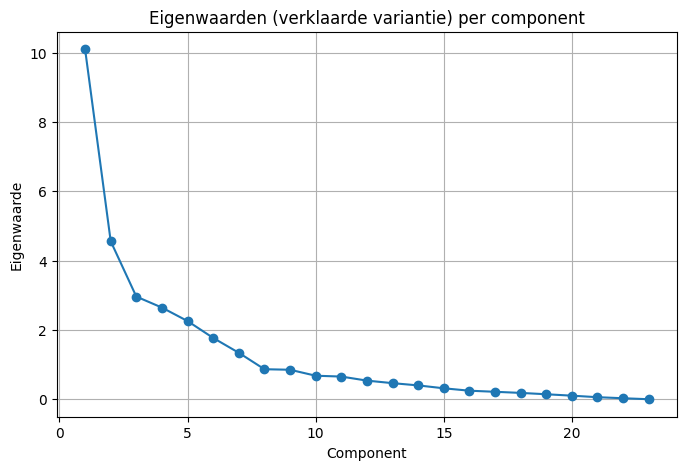


=== PCA BIPLOT ===


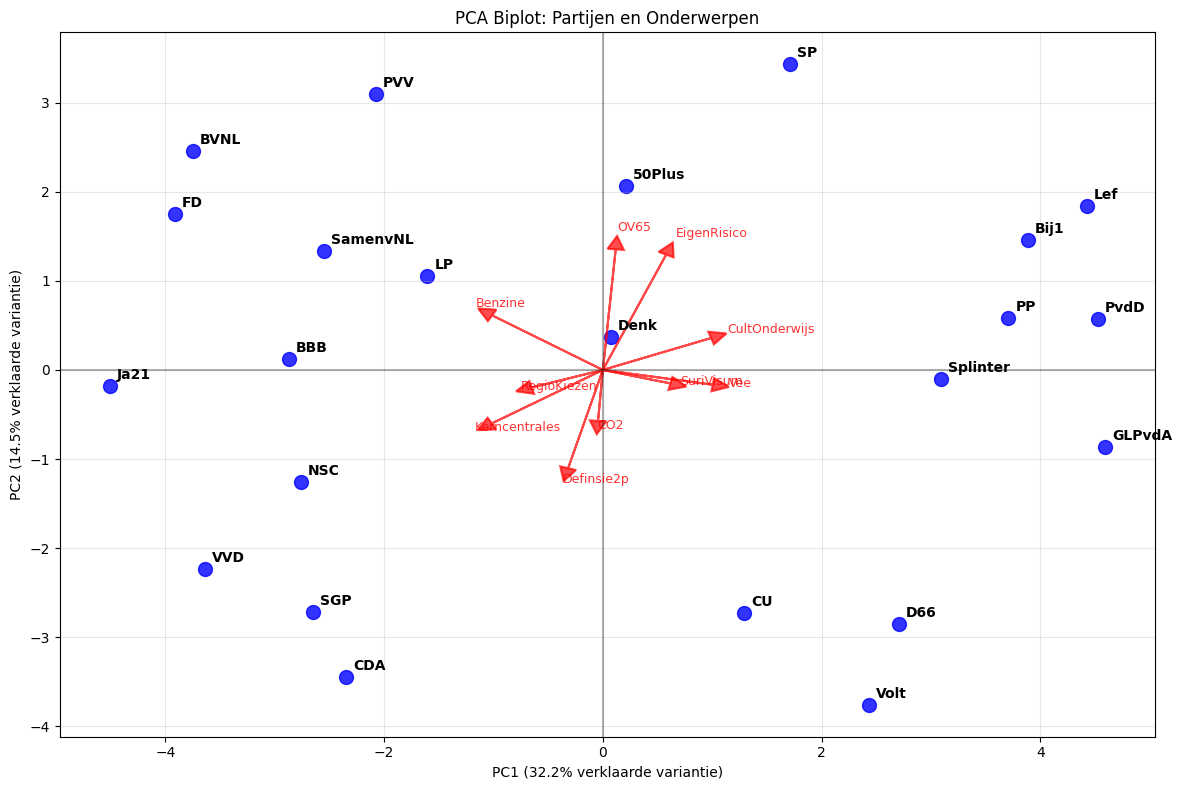


PC1 verklaart 32.2% van de variantie
PC2 verklaart 14.5% van de variantie
Samen verklaren ze 46.7% van de totale variantie

Interpretatie:
- Blauwe punten = partijen in 2D PCA ruimte
- Rode pijlen = onderwerpen die de componenten bepalen
- Partijen dicht bij elkaar hebben vergelijkbare standpunten
- Pijlen in dezelfde richting horen bij elkaar


In [16]:
#3.	Bepalen van eigenwaarden en eigenvectoren: Deze wiskundige begrippen geven richting en grootte van de variantie in de data aan
# Extract party data (exclude first column 'Partij') and transpose for PCA
partij_data = df.iloc[:, 1:]  # All columns except first (Partij)
partij_data_scaled = df_scaled  # Use the already scaled data

pca = PCA()
pca.fit(partij_data_scaled)
eigenwaarden = pca.explained_variance_
eigenvectoren = pca.components_

print("Eigenwaarden (verklaarde variantie):")
print(eigenwaarden)
print("\nEigenwaarden ratio (percentage verklaarde variantie):")
print(pca.explained_variance_ratio_)
print(f"\nVorm van eigenvectoren matrix: {eigenvectoren.shape}")
print("(Elke rij is een eigenvector/principal component)")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenwaarden) + 1), eigenwaarden, marker='o')
plt.title("Eigenwaarden (verklaarde variantie) per component")
plt.xlabel("Component")
plt.ylabel("Eigenwaarde")
plt.grid()
plt.show()

# BIPLOT TOEVOEGEN OP BASIS VAN BESTAANDE PCA
import numpy as np

# Transform data naar PCA space
pca_scores = pca.transform(partij_data_scaled)

# Maak DataFrames voor scores en loadings
dfScores = pd.DataFrame(pca_scores[:, :2], columns=['PC1', 'PC2'], index=df.iloc[:, 0])  # Partijnamen
dfLoadings = pd.DataFrame(eigenvectoren[:2, :].T, columns=['PC1', 'PC2'], 
                         index=partij_data.columns)  # Onderwerp namen

def biplot(scores_df, loadings_df, pca_obj):
    """
    Maak biplot met bestaande PCA waarden
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot partijen (scores)
    ax.scatter(scores_df['PC1'], scores_df['PC2'], s=100, alpha=0.8, color='blue')
    
    # Voeg partijnamen toe
    for i, party in enumerate(scores_df.index):
        ax.annotate(party, (scores_df.iloc[i, 0], scores_df.iloc[i, 1]), 
                   xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')
    
    # Plot loadings (onderwerpen) als pijlen
    scale_factor = 4  # Schaal voor betere visualisatie
    
    for i in range(min(10, len(loadings_df))):  # Toon alleen eerste 10 onderwerpen
        tipx = loadings_df.iloc[i, 0] * scale_factor
        tipy = loadings_df.iloc[i, 1] * scale_factor
        ax.arrow(0, 0, tipx, tipy, color='red', alpha=0.7, 
                head_width=0.15, head_length=0.15, linewidth=1.5)
        ax.text(tipx * 1.15, tipy * 1.15, loadings_df.index[i], 
               fontsize=9, color='red', alpha=0.8)
    
    # Labels en titels
    explvar = pca_obj.explained_variance_ratio_
    ax.set_xlabel(f'PC1 ({explvar[0]:.1%} verklaarde variantie)')
    ax.set_ylabel(f'PC2 ({explvar[1]:.1%} verklaarde variantie)')
    ax.set_title('PCA Biplot: Partijen en Onderwerpen')
    
    # Grid en layout
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Genereer de biplot
print("\n=== PCA BIPLOT ===")
biplot(dfScores, dfLoadings, pca)

# Print extra informatie
print(f"\nPC1 verklaart {pca.explained_variance_ratio_[0]:.1%} van de variantie")
print(f"PC2 verklaart {pca.explained_variance_ratio_[1]:.1%} van de variantie") 
print(f"Samen verklaren ze {pca.explained_variance_ratio_[:2].sum():.1%} van de totale variantie")

print("\nInterpretatie:")
print("- Blauwe punten = partijen in 2D PCA ruimte")
print("- Rode pijlen = onderwerpen die de componenten bepalen")
print("- Partijen dicht bij elkaar hebben vergelijkbare standpunten")
print("- Pijlen in dezelfde richting horen bij elkaar")